<a href="https://colab.research.google.com/github/abrar2akib/Sample-Codes/blob/main/UChicago%20Predoc%20Code/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Full absolute path
data_path_crsp = "/content/drive/MyDrive/Colab Notebooks/PreDocPrep/FMC_RP_Abrar/data/crsp.csv"
data_path_comp = "/content/drive/MyDrive/Colab Notebooks/PreDocPrep/FMC_RP_Abrar/data/comp.csv"
data_path_lintable= "/content/drive/MyDrive/Colab Notebooks/PreDocPrep/FMC_RP_Abrar/data/linktable.csv"

comp = pd.read_csv(data_path_comp)
crsp = pd.read_csv(data_path_crsp)
linktable = pd.read_csv(data_path_lintable)

# Loop directly over variable names
for var_name in ["crsp", "comp", "linktable"]:
    df = globals()[var_name]   # get the variable by name
    print(f"{var_name} shape: {df.shape}")

crsp shape: (458670, 6)
comp shape: (141625, 17)
linktable shape: (10465, 6)


#Cleaning CRSP

In [ ]:
# Converting data types
crsp['permno'] = crsp['permno'].astype(int)
crsp['date'] = pd.to_datetime(crsp['date'])
crsp['prc'] = pd.to_numeric(crsp['prc'], errors='coerce')
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')
crsp['dlret'] = pd.to_numeric(crsp['dlret'], errors='coerce')
crsp['shrout'] = pd.to_numeric(crsp['shrout'], errors='coerce')

# Handling missing/invalid prices and shares
crsp = crsp[crsp['prc'].notna() & (crsp['prc'] != 0)]
crsp = crsp[crsp['shrout'].notna() & (crsp['shrout'] > 0)]

# Removing duplicates
crsp = crsp.drop_duplicates(subset=['permno', 'date'], keep='last')

# Flagging delisted stocks
crsp['is_delisted'] = crsp['dlret'].notna()

# Sorting by permno and date
crsp = crsp.sort_values(by=['permno', 'date']).reset_index(drop=True)

# Checking cleaned data
print(crsp.info())
print(crsp.head())
print(f"Number of unique securities: {crsp['permno'].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458634 entries, 0 to 458633
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   permno       458634 non-null  int64         
 1   date         458634 non-null  datetime64[ns]
 2   ret          455826 non-null  float64       
 3   shrout       458634 non-null  float64       
 4   prc          458634 non-null  float64       
 5   dlret        328 non-null     float64       
 6   is_delisted  458634 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1)
memory usage: 21.4 MB
None
   permno       date       ret   shrout    prc  dlret  is_delisted
0   10001 2014-01-31  0.147572  10452.0   9.17    NaN        False
1   10001 2014-02-28  0.025627  10452.0   9.36    NaN        False
2   10001 2014-03-31  0.079594  10452.0  10.06    NaN        False
3   10001 2014-04-30  0.087972  10488.0  10.90    NaN        False
4   10001 2014-05-30 

# CRSP: Value-weighted market return series

## Computing cum-dividend total returns

In [ ]:
# Vectorized computation of retadj
crsp['retadj'] = np.where(
    crsp['ret'].notna() & crsp['dlret'].isna(),
    crsp['ret'],  # only ret exists
    np.where(
        crsp['ret'].isna() & crsp['dlret'].notna(),
        crsp['dlret'],  # only dlret exists
        np.where(
            crsp['ret'].notna() & crsp['dlret'].notna(),
            (1 + crsp['ret']) * (1 + crsp['dlret']) - 1,  # both exist
            np.nan  # both missing
        )
    )
)

# Checking results
crsp.head()


,permno,date,ret,shrout,prc,dlret,is_delisted,retadj
0,10001,2014-01-31,0.147572,10452.0,9.17,NaN,False,0.147572
1,10001,2014-02-28,0.025627,10452.0,9.36,NaN,False,0.025627
2,10001,2014-03-31,0.079594,10452.0,10.06,NaN,False,0.079594
3,10001,2014-04-30,0.087972,10488.0,10.90,NaN,False,0.087972
4,10001,2014-05-30,-0.033486,10488.0,10.49,NaN,False,-0.033486


## Constructing a value-weighted market return series

In [ ]:
# Step 1: Compute market equity (ME)
# Convert shares outstanding to actual number of shares (shrout is in 1000s)
crsp['ME'] = crsp['prc'].abs() * crsp['shrout'] * 1000  # in dollars

# Step 2: Sort by permno and date
crsp = crsp.sort_values(by=['permno', 'date']).reset_index(drop=True)

# Step 3: Compute lagged market equity (previous month)
crsp['ME_lag'] = crsp.groupby('permno')['ME'].shift(1)

# Step 4: Compute total lagged market equity for each month
total_ME_lag = crsp.groupby('date')['ME_lag'].sum().rename('total_ME_lag')

# Merge total lagged ME back to crsp
crsp = crsp.merge(total_ME_lag, on='date', how='left')

# Step 5: Compute weights
crsp['weight'] = crsp['ME_lag'] / crsp['total_ME_lag']

# Step 6: Compute value-weighted return for each month
vw_returns = crsp.groupby('date').apply(lambda x: np.sum(x['weight'] * x['retadj'])).rename('R_m')

# Step 7: Compute cumulative index (starting at 100)
cumulative_index = (1 + vw_returns).cumprod() * 100

# # Step 8: Plot the cumulative index
# plt.rcParams['font.family'] = 'DejaVu Serif'  # serif font
# plt.figure(figsize=(12,6))
# plt.plot(cumulative_index.index, cumulative_index.values, color='blue', linewidth=2,label='CRSP Value-Weighted Market Index')

# plt.xlabel('Months', fontname='DejaVu Serif')
# plt.axhline(y=100, color='red', linestyle='--', linewidth=2)
# plt.tick_params(axis='both', labelsize=12)
# plt.ylabel('Cumulative Index (Base = 100)', fontname='DejaVu Serif')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-07-01'), color='red', alpha=0.1)
# plt.axvspan(pd.Timestamp('2021-10-01'), pd.Timestamp('2022-03-01'), color='red', alpha=0.1)
# plt.axvspan(pd.Timestamp('2022-08-01'), pd.Timestamp('2022-12-01'), color='red', alpha=0.1)
# plt.legend()
# plt.tight_layout()
# plt.savefig("CRSP_Value_Weighted_Index.pdf", format='pdf', dpi=300)
# plt.show()


/tmp/ipython-input-3659274838.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vw_returns = crsp.groupby('date').apply(lambda x: np.sum(x['weight'] * x['retadj'])).rename('R_m')


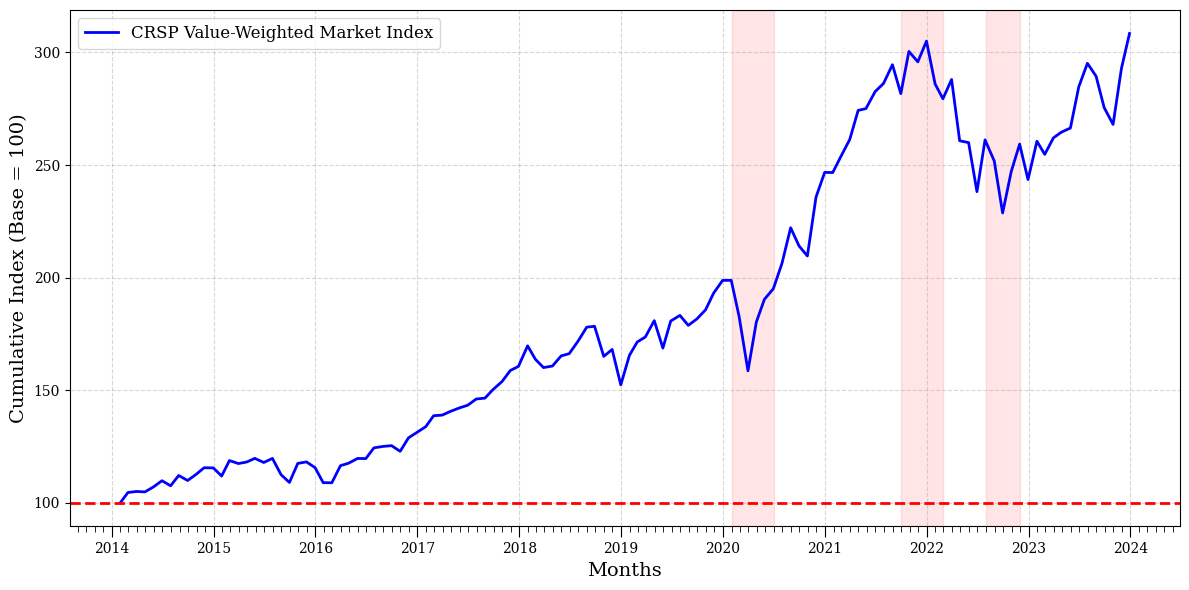

In [ ]:
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'DejaVu Serif'  # serif font
plt.figure(figsize=(12,6))
plt.plot(cumulative_index.index, cumulative_index.values, color='blue', linewidth=2, label='CRSP Value-Weighted Market Index')

# Labels
plt.xlabel('Months', fontsize=14)
plt.ylabel('Cumulative Index (Base = 100)', fontsize=14)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Base line
plt.axhline(y=100, color='red', linestyle='--', linewidth=2)

# Highlight periods
plt.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-07-01'), color='red', alpha=0.1)
plt.axvspan(pd.Timestamp('2021-10-01'), pd.Timestamp('2022-03-01'), color='red', alpha=0.1)
plt.axvspan(pd.Timestamp('2022-08-01'), pd.Timestamp('2022-12-01'), color='red', alpha=0.1)

# Legend
plt.legend(fontsize=12)

# X-axis ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())      # major ticks: start of each year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # label only the year
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=range(1,13)))  # minor ticks: every month
ax.tick_params(axis='x', which='minor', length=4)  # shorter ticks for months
ax.tick_params(axis='x', which='major', length=8)  # longer ticks for years

plt.tight_layout()
plt.savefig("CRSP_Value_Weighted_Index.pdf", format='pdf', dpi=300)
plt.show()

# Compustat and Linktable

In [ ]:
print(comp.info())
print(comp.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141625 entries, 0 to 141624
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gvkey     141625 non-null  int64  
 1   datadate  141625 non-null  object 
 2   fyear     141625 non-null  float64
 3   fyr       141625 non-null  float64
 4   seq       101544 non-null  float64
 5   txditc    90808 non-null   float64
 6   pstk      101252 non-null  float64
 7   pstkl     100605 non-null  float64
 8   pstkrv    100668 non-null  float64
 9   at        101549 non-null  float64
 10  capx      100325 non-null  float64
 11  ppent     99038 non-null   float64
 12  ppegt     87497 non-null   float64
 13  xrd       46315 non-null   float64
 14  xsga      84663 non-null   float64
 15  sic       141625 non-null  int64  
 16  naics     135303 non-null  float64
dtypes: float64(14), int64(2), object(1)
memory usage: 18.4+ MB
None
   gvkey    datadate   fyear  fyr      seq   txditc  pstk  p

In [ ]:
print(linktable.info())
print(linktable.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10465 entries, 0 to 10464
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gvkey      10465 non-null  int64  
 1   permno     10465 non-null  float64
 2   linktype   10465 non-null  object 
 3   linkprim   10465 non-null  object 
 4   linkdt     10465 non-null  object 
 5   linkenddt  4431 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 490.7+ KB
None
   gvkey   permno linktype linkprim      linkdt   linkenddt
0   1004  54594.0       LU        P  1972-04-24         NaN
1   1045  21020.0       LC        P  2013-12-09         NaN
2   1050  11499.0       LC        P  1980-11-28         NaN
3   1062  26649.0       LU        P  1965-01-29         NaN
4   1072  81912.0       LC        C  1995-08-15  2020-03-27


In [ ]:
# Converting datadate to datetime
comp['datadate'] = pd.to_datetime(comp['datadate'], errors='coerce')

# Checking for parsing issues
print("Missing datadate:", comp['datadate'].isna().sum())

# Checking for missing or duplicate gvkey
print("Missing gvkey:", comp['gvkey'].isna().sum())
print("Duplicate gvkey–datadate pairs:", comp.duplicated(subset=['gvkey', 'datadate']).sum())

# Ensuring fiscal year is integer
comp['fyear'] = comp['fyear'].astype('Int64', errors='ignore')

# Checking that datadate roughly corresponds to fyear
# For example, ensure fyear matches datadate.year within a one-year lag tolerance
mismatch = comp.loc[~((comp['datadate'].dt.year.isin([comp['fyear'], comp['fyear'] + 1])))]

print("Potential year mismatch:", mismatch.shape[0])

# Checking for duplicates on gvkey + datadate
num_dupes = comp.duplicated(subset=['gvkey', 'datadate']).sum()
print(f"Number of duplicate gvkey–datadate pairs: {num_dupes}")

# Inspecting duplicate rows (optional preview)
if num_dupes > 0:
    print("Example duplicates:")
    display(comp[comp.duplicated(subset=['gvkey', 'datadate'], keep=False)].head())

# Checking for missing total assets (at)       //total assets missing is suspicious
num_missing_at = comp['at'].isna().sum()
print(f"Number of rows with missing total assets (at): {num_missing_at}")

Missing datadate: 0
Missing gvkey: 0
Duplicate gvkey–datadate pairs: 0
Potential year mismatch: 141625
Number of duplicate gvkey–datadate pairs: 0
Number of rows with missing total assets (at): 40076


#Constructing Book Equity (be)

In [ ]:
# Constructing preferred stock value (BVPS) using hierarchy
comp['bvps'] = np.where(~comp['pstkrv'].isna(), comp['pstkrv'],
                 np.where(~comp['pstkl'].isna(), comp['pstkl'],
                 np.where(~comp['pstk'].isna(),  comp['pstk'], 0)))

# Replaceing missing TXDITC or SEQ with 0 if necessary
# (Optional: some researchers prefer leaving them NaN, but Fama–French treat missing as 0)
comp['txditc'] = comp['txditc'].fillna(0)
comp['seq'] = comp['seq'].fillna(0)

# Computing book equity (BE)
comp['be'] = comp['seq'] + comp['txditc'] - comp['bvps']

# Checking sanity
print("Missing BE values:", comp['be'].isna().sum())
print("Negative BE values:", (comp['be'] < 0).sum())

# Inspecting a few examples
comp[['gvkey', 'fyear', 'seq', 'txditc', 'pstkrv', 'pstkl', 'pstk', 'bvps', 'be']].head(10)


Missing BE values: 0
Negative BE values: 14310


,gvkey,fyear,seq,txditc,pstkrv,pstkl,pstk,bvps,be
0,1004,2011,864.649,115.908,0.0,0.0,0.0,0.0,980.557
1,1004,2012,918.600,138.200,0.0,0.0,0.0,0.0,1056.800
2,1004,2013,999.500,162.200,0.0,0.0,0.0,0.0,1161.700
3,1004,2014,845.100,104.600,0.0,0.0,0.0,0.0,949.700
4,1004,2015,865.800,34.300,0.0,0.0,0.0,0.0,900.100
5,1004,2016,914.200,37.200,0.0,0.0,0.0,0.0,951.400
6,1004,2017,936.300,15.700,0.0,0.0,0.0,0.0,952.000
7,1004,2018,905.900,0.000,0.0,0.0,0.0,0.0,905.900
8,1004,2019,902.600,0.000,0.0,0.0,0.0,0.0,902.600
9,1004,2020,974.400,9.500,0.0,0.0,0.0,0.0,983.900


# Assignment following June Convention

In [ ]:
# Converting date columns to datetime where necessary
crsp['date'] = pd.to_datetime(crsp['date'])
comp['datadate'] = pd.to_datetime(comp['datadate'])
linktable['linkdt'] = pd.to_datetime(linktable['linkdt'])
linktable['linkenddt'] = pd.to_datetime(linktable['linkenddt'])

# Defining start and end months under June–t convention
comp['start_month'] = pd.to_datetime(comp['fyear'] + 1, format='%Y') + pd.offsets.MonthBegin(6)  # July (t+1)
comp['end_month']   = pd.to_datetime(comp['fyear'] + 2, format='%Y') + pd.offsets.MonthBegin(5)  # June (t+2)

from pandas.tseries.offsets import MonthEnd

# Generating the list of all month-end dates we might need
all_months = pd.date_range(
    start=comp['start_month'].min(),
    end=comp['end_month'].max(),
    freq='M'
)

# Build a DataFrame mapping each month to its fiscal year interval
# (This uses an efficient join instead of expanding each row manually)
comp_expanded = (
    comp.loc[:, ['gvkey', 'fyear', 'datadate', 'start_month', 'end_month']]
        .merge(pd.DataFrame({'month': all_months}), how='cross')   # Cartesian join
)

# Filter only months within each firm's start–end range
comp_expanded = comp_expanded[
    (comp_expanded['month'] >= comp_expanded['start_month']) &
    (comp_expanded['month'] <= comp_expanded['end_month'])
]

# Drop unneeded range columns
comp_expanded = comp_expanded.drop(columns=['start_month', 'end_month'])

# Merge back the fundamentals from comp (vectorized join on gvkey + fyear + datadate)
comp_expanded = comp_expanded.merge(
    comp.drop(columns=['start_month', 'end_month']),
    on=['gvkey', 'fyear', 'datadate'],
    how='left'
)

# Optional: ensure month is month-end aligned (for CRSP match)
comp_expanded['month'] = comp_expanded['month'] + MonthEnd(0)

/tmp/ipython-input-4258787642.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  all_months = pd.date_range(


# Merge all three

In [ ]:
# Merging Compustat (gvkey) with linktable
comp_linked = comp_expanded.merge(linktable, on='gvkey', how='left')

# Keeping rows where the Compustat month lies within link validity window
# Handle open-ended linkenddt as 'infinity' by filling with a large date
comp_linked['linkenddt'] = comp_linked['linkenddt'].fillna(pd.Timestamp('today') + pd.DateOffset(years=100))
comp_linked = comp_linked[
    (comp_linked['month'] >= comp_linked['linkdt']) & (comp_linked['month'] <= comp_linked['linkenddt'])
]
# Defining priority orders
linkprim_priority = {'P': 1, 'C': 2}
linktype_priority = {'LC': 1, 'LU': 2, 'LN': 3, 'LD': 4}

comp_linked['linkprim_rank'] = comp_linked['linkprim'].map(linkprim_priority)
comp_linked['linktype_rank'] = comp_linked['linktype'].map(linktype_priority)

# Sorting by priorities and drop duplicates to keep the "best" link
comp_linked = comp_linked.sort_values(['permno', 'month', 'linkprim_rank', 'linktype_rank'])
comp_linked = comp_linked.drop_duplicates(subset=['permno', 'month'], keep='first')

# Merging Compustat-linked dataset with CRSP monthly data
merged = crsp.merge(
    comp_linked,
    how='left',
    left_on=['permno', 'date'],
    right_on=['permno', 'month']
)

# Keeping only firm-months that fall into the June–t convention mapping
merged = merged.drop(columns=['linkprim_rank', 'linktype_rank'])

# Ensuring one unique record per firm–month
merged = merged.drop_duplicates(subset=['permno', 'date'])

# Sorting for clarity
merged = merged.sort_values(['permno', 'date']).reset_index(drop=True)

# Checking structure
print(merged[['permno', 'date', 'gvkey', 'ret', 'seq', 'at', 'fyear']].head())

merged.info()

   permno       date    gvkey       ret     seq       at  fyear
0   10001 2014-01-31  12994.0  0.147572  76.344  174.463   2012
1   10001 2014-02-28  12994.0  0.025627  76.344  174.463   2012
2   10001 2014-03-31  12994.0  0.079594  76.344  174.463   2012
3   10001 2014-04-30  12994.0  0.087972  76.344  174.463   2012
4   10001 2014-05-30      NaN -0.033486     NaN      NaN   <NA>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458634 entries, 0 to 458633
Data columns (total 36 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   permno        458634 non-null  int64         
 1   date          458634 non-null  datetime64[ns]
 2   ret           455826 non-null  float64       
 3   shrout        458634 non-null  float64       
 4   prc           458634 non-null  float64       
 5   dlret         328 non-null     float64       
 6   is_delisted   458634 non-null  bool          
 7   retadj        455827 non-null  float64   

#Summary Statistics

## Summary Stats without Winsorization

In [ ]:


# List of variables
vars_to_summarize = ['ret', 'prc', 'at', 'capx', 'xrd', 'be']

# Create summary table from original data
summary = pd.DataFrame(index=vars_to_summarize)
summary['missing'] = merged[vars_to_summarize].isna().sum()
summary['non_missing'] = merged[vars_to_summarize].notna().sum()
summary['count'] = merged[vars_to_summarize].count()
summary['mean'] = merged[vars_to_summarize].mean()
summary['std'] = merged[vars_to_summarize].std()
summary['min'] = merged[vars_to_summarize].min()
summary['max'] = merged[vars_to_summarize].max()
summary['skew'] = merged[vars_to_summarize].skew()

# Display the summary
summary


,missing,non_missing,count,mean,std,min,max,skew
ret,2808,455826,455826,0.006270,0.203520,-0.99569,1.988359e+01,13.404525
prc,0,458634,458634,125.909821,5441.456346,-1010.53497,5.467250e+05,71.245611
at,178063,280571,280571,11764.863417,88692.399018,0.00000,3.743567e+06,22.471027
capx,179548,279086,279086,243.985046,1309.875878,-3258.00000,6.364500e+04,16.074836
xrd,302707,155927,155927,197.577649,1282.407639,-0.64800,7.321300e+04,20.843906
be,175888,282746,282746,2645.828059,13807.557120,-22671.00000,5.958780e+05,16.288922


## Summary Stats with Winsorization

In [ ]:
# List of variables
vars_to_summarize = ['ret', 'prc', 'at', 'capx', 'xrd', 'be']

# Winsorize at 1% and 99%
def winsorize_series(s, lower=0.01, upper=0.99):
    return s.clip(lower=s.quantile(lower), upper=s.quantile(upper))


winsor_limits = {
    'ret': (0.005, 0.995), # Extremely right-skewed due to huge outliers; natural returns usually don’t exceed ±1 for monthly returns.
    'prc': (0.01, 0.99),  # Extremely right-skewed; negative and huge max are data errors/outliers.
    'at': (0.005, 0.995), # Very heavy right tail; a few very large firms dominate the distribution.
    'capx': (0.0, 0.99), # Right-skewed; negative min may be accounting adjustments, many small values near zero. 0%–99% to keep zeros and only remove extreme high outliers.
    'xrd': (0.0, 0.99),  # Right-skewed, many zeros, some huge R&D spenders.
    'be': (0.01, 0.99)   # Right-skewed, negative BE exists, extreme large firms dominate.
}

# Winsorize function with variable-specific percentiles
def winsorize_series(s, lower, upper):
    return s.clip(lower=s.quantile(lower), upper=s.quantile(upper))

# Create a winsorized dataframe
df_winsor = merged.copy()
for v in vars_to_summarize:
    lower, upper = winsor_limits[v]
    df_winsor[v] = winsorize_series(df_winsor[v].dropna(), lower, upper)

# Create summary table
summary = pd.DataFrame(index=vars_to_summarize)
summary['missing'] = df_winsor[vars_to_summarize].isna().sum()
summary['non_missing'] = df_winsor[vars_to_summarize].notna().sum()
summary['count'] = df_winsor[vars_to_summarize].count()
summary['mean'] = df_winsor[vars_to_summarize].mean()
summary['std'] = df_winsor[vars_to_summarize].std()
summary['min'] = df_winsor[vars_to_summarize].min()
summary['max'] = df_winsor[vars_to_summarize].max()
summary['skew'] = df_winsor[vars_to_summarize].skew()

# Display
summary


,missing,non_missing,count,mean,std,min,max,skew
ret,2808,455826,455826,0.003496,0.159232,-0.513086,0.795500,0.860325
prc,0,458634,458634,37.978878,57.220834,-10.020000,361.106697,3.279728
at,178063,280571,280571,8689.872748,32988.342417,1.636250,332750.000000,7.275378
capx,179548,279086,279086,184.684769,605.202984,-3258.000000,4347.000000,5.190735
xrd,302707,155927,155927,140.554816,508.328477,-0.648000,4207.000000,6.425451
be,175888,282746,282746,2028.715656,6034.862830,-604.400000,43742.000000,5.115451


#Saving hhe Merged Dataset

In [ ]:
# Save DataFrame as Stata file (.dta)
merged.to_stata('/content/merged.dta', write_index=False)

# Save DataFrame as CSV
merged.to_csv('/content/merged.csv', index=False)


In [ ]:
# Count number of duplicate permno-fyear combinations
dup_permno_fyear = merged.duplicated(subset=['permno', 'fyear'], keep=False)
print("Number of permno-fyear duplicates:", dup_permno_fyear.sum())

# Count number of duplicate permno-month combinations
dup_permno_month = merged.duplicated(subset=['permno', 'month'], keep=False)
print("Number of permno-month duplicates:", dup_permno_month.sum())


Number of permno-fyear duplicates: 458101
Number of permno-month duplicates: 175840


In [ ]:
merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458634 entries, 0 to 458633
Data columns (total 36 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   permno        458634 non-null  int64         
 1   date          458634 non-null  datetime64[ns]
 2   ret           455826 non-null  float64       
 3   shrout        458634 non-null  float64       
 4   prc           458634 non-null  float64       
 5   dlret         328 non-null     float64       
 6   is_delisted   458634 non-null  bool          
 7   retadj        455827 non-null  float64       
 8   ME            458634 non-null  float64       
 9   ME_lag        452111 non-null  float64       
 10  total_ME_lag  458634 non-null  float64       
 11  weight        452111 non-null  float64       
 12  gvkey         282746 non-null  float64       
 13  fyear         282746 non-null  Int64         
 14  datadate      282746 non-null  datetime64[ns]
 15  month         282

In [ ]:
merged[['permno', 'date']].duplicated().sum()
## for proceeding to panel regression entity and time is needed

np.int64(0)